<a href="https://colab.research.google.com/github/Gabriel-Orlandi-Portes/Analise-Album-Copa2026/blob/main/analise_album_copa2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. 📊 Análise das Simulações do Álbum da Copa do Mundo 2026**

Este notebook tem como objetivo analisar os dados gerados através das **1.000 simulações** do álbum da Copa do Mundo 2026.

A simulação foi criada em Python e modela a abertura de pacotes com reposição — ou seja, a mesma figurinha pode aparecer mais de uma vez no mesmo pacote, assim como acontece na vida real.

O objetivo é estimar:

- Quantidade de pacotes necessários para completar o álbum
- Custo total da coleção
- Quantidade de figurinhas repetidas
- Diferença entre repetidas normais e brilhantes
- Distribuição e variação dos resultados entre simulações

Os dados utilizados neste notebook foram gerados pelo arquivo `1000_simulacoes.py`.

---


# **2. 📚 Importação das Bibliotecas**

Nesta etapa são importadas as bibliotecas utilizadas durante toda a análise:

- **Pandas:** manipulação e análise dos dados
- **Matplotlib:** criação das visualizações gráficas
- **NumPy:** cálculos estatísticos adicionais (intervalo de confiança)

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!




---



#**3. 📥 Carregamento e Leitura dos Dados**

Os dados utilizados na análise estão armazenados no arquivo `simulacoes.csv`.

*   O arquivo será carregado utilizando o Pandas para criação de um DataFrame.

*   O DataFrame será utilizado para realizar todas as análises posteriores.

In [3]:
# Selecionar arquivo simulacoes.csv

from google.colab import files

uploaded = files.upload()

#CASO ESTEJA USANDO O VS CODE UTILIZAR O CÓDIGO ABAIXO:
#df = pd.read_csv("../data/simulacoes.csv")

Saving simulacoes.csv to simulacoes.csv


In [4]:
# Carregando a tabela...

df = pd.read_csv('simulacoes.csv')

print('Tabela carregada com sucesso!')

Tabela carregada com sucesso!




---



#**4. 🔎 Exploração Inicial dos Dados**

Antes de iniciar as análises, é feita uma exploração inicial do dataset.

O objetivo é entender:

- Estrutura dos dados e quantidade de registros
- Tipos das variáveis
- Estatísticas básicas das colunas
- Possíveis inconsistências ou valores ausentes

In [5]:
# Primeiras linhas do dataset.
df.head()

,pacotes,custo,repetidas_total,repetidas_normais,repetidas_brilhantes
0,1160,8195,7140,6650,490
1,944,6683,5628,5187,441
2,833,5906,4851,4486,365
3,854,6053,4998,4655,343
4,1055,7460,6405,5940,465


In [6]:
# Quantidade de linhas e colunas.
df.shape

(1000, 5)

In [7]:
# Variáveis, tipos e valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   pacotes               1000 non-null   int64
 1   custo                 1000 non-null   int64
 2   repetidas_total       1000 non-null   int64
 3   repetidas_normais     1000 non-null   int64
 4   repetidas_brilhantes  1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [8]:
# Dados Estatísticos da tabela
df.describe()

,pacotes,custo,repetidas_total,repetidas_normais,repetidas_brilhantes
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1045.560000,7393.920000,6338.920000,5898.275000,440.645000
std,182.725595,1279.079165,1279.079165,1190.468144,91.409292
min,669.000000,4758.000000,3703.000000,3412.000000,266.000000
25%,920.000000,6515.000000,5460.000000,5074.750000,376.000000
50%,1013.000000,7166.000000,6111.000000,5684.500000,426.000000
75%,1131.250000,7993.750000,6938.750000,6457.000000,486.000000
max,1881.000000,13242.000000,12187.000000,11298.000000,889.000000


In [9]:
# Padronizando nome das colunas para facilitar a análise

df.rename(
    columns={
        'pacotes': 'pacotes_comprados',
        'custo': 'custo_total'
    },
    inplace=True
)

**Conclusão**

O dataset contém **1.000 registros** e **5 variáveis**, todas numéricas e sem valores ausentes:

- `pacotes_comprados`: quantidade de pacotes comprados na simulação
- `custo_total`: custo final incluindo o valor do álbum (R$ 75,00)
- `repetidas_total`: total de figurinhas repetidas acumuladas
- `repetidas_normais`: repetidas de figurinhas comuns
- `repetidas_brilhantes`: repetidas de figurinhas especiais

O `describe()` já antecipa que existe variação significativa entre simulações — a diferença entre mínimo e máximo de pacotes é grande, o que será explorado nas seções seguintes.

---

---

Antes de iniciar as análises por variável, é importante entender as medidas estatísticas que serão utilizadas ao longo do notebook.

**Média:** valor médio de um conjunto de dados, calculado pela soma de todos os valores dividida pela quantidade de elementos.

**Valores Mínimos e Máximos:** representam os extremos encontrados entre todas as simulações, mostrando o melhor e o pior cenário possível.

**Mediana:** valor central dos dados quando ordenados. Metade das simulações ficou abaixo dela, metade acima. É menos sensível a valores extremos do que a média.

**Quartis:** dividem os dados em quatro partes iguais:
- **Q1 (25%):** 25% das simulações ficaram abaixo desse valor
- **Q2 (50%):** equivale à mediana
- **Q3 (75%):** 75% das simulações ficaram abaixo desse valor

---

# **5. 📦 Análise da Quantidade de Pacotes Necessários**

#### **5.1 Média**

In [10]:
media_pacotes = df["pacotes_comprados"].mean()

print(f'Média de pacotes necessários: {media_pacotes:.0f}')

Média de pacotes necessários: 1046


**Conclusão**

Com base nas 1.000 simulações, a média foi de aproximadamente **1.046 pacotes** para completar o álbum.

Esse é o resultado esperado para um colecionador médio que compra pacotes aleatoriamente e não realiza nenhuma troca com outros colecionadores.

---

#### **5.2 Valores Mínimos e Máximos**

In [11]:
menor_quantidade = df['pacotes_comprados'].min()
maior_quantidade = df['pacotes_comprados'].max()

print(f'Menor quantidade encontrada: {menor_quantidade}')
print(f'Maior quantidade encontrada: {maior_quantidade}')
print(f'Diferença entre melhor e pior caso: {maior_quantidade - menor_quantidade} pacotes')

Menor quantidade encontrada: 669
Maior quantidade encontrada: 1881
Diferença entre melhor e pior caso: 1212 pacotes


**Conclusão**

O **melhor cenário** completou o álbum com apenas **669 pacotes**, enquanto o **pior cenário** precisou de **1.881 pacotes** — uma diferença de mais de **1.200 pacotes** entre as simulações extremas.

Essa variação expressiva evidencia o impacto da aleatoriedade: dois colecionadores partindo das mesmas condições podem ter experiências financeiras completamente diferentes.

---

#### **5.3 Mediana**

In [12]:
mediana_pacotes = df["pacotes_comprados"].median()

print(f'Mediana de pacotes: {mediana_pacotes:.0f}')

Mediana de pacotes: 1013


**Conclusão**

A mediana foi de **1.013 pacotes**, valor próximo à média de **1.046 pacotes**.

Quando média e mediana estão próximas, indica que a distribuição é razoavelmente equilibrada — os valores extremos (como o caso de 1.881 pacotes) existem, mas não distorcem muito o comportamento típico. Isso ficará mais visível no histograma da seção 5.5.

---

#### **5.4 Quartis**

In [13]:
quartis_pacotes = df["pacotes_comprados"].quantile([0.25, 0.50, 0.75])

quartis_pacotes

,pacotes_comprados
0.25,920.00
0.50,1013.00
0.75,1131.25


**Conclusão**

Os quartis mostram onde está concentrada a maior parte das simulações:

- **25% das simulações** completaram o álbum com até **920 pacotes**
- **75% das simulações** completaram o álbum com até **1.131 pacotes**
- Portanto, **50% das simulações** ficaram na faixa de **920 a 1.131 pacotes**

Isso significa que a maioria dos colecionadores pode esperar gastar entre esses dois valores, quem gastar muito mais do que isso está no grupo dos azarados.

---

#### **5.5 Distribuição de pacotes necessários — Histograma**

O histograma mostra como os resultados das 1.000 simulações se distribuem em relação à quantidade de pacotes.

As linhas verticais indicam a **média** e a **mediana**, permitindo visualizar onde está concentrado o comportamento mais comum.

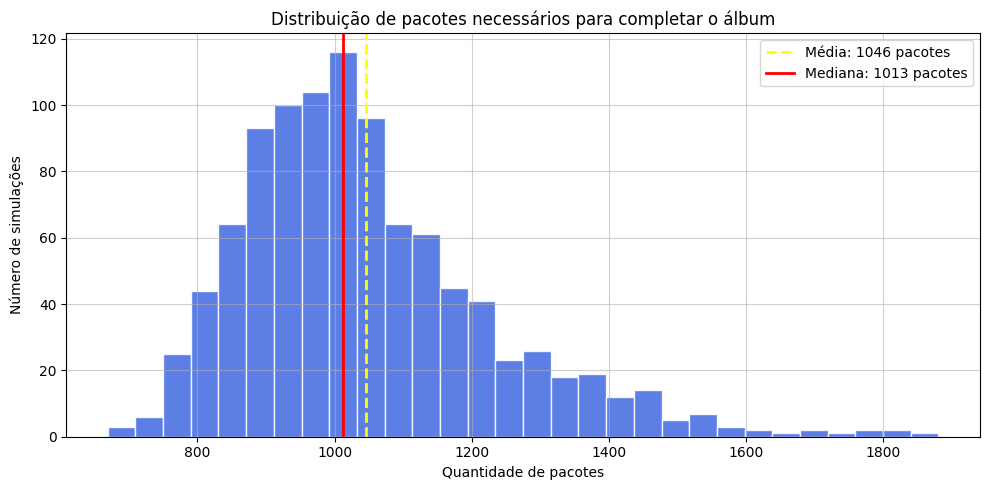

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(df['pacotes_comprados'], bins=30, color='royalblue', alpha=0.85, edgecolor='white')

plt.axvline(media_pacotes, linestyle='--', linewidth=2, color='yellow',
            label=f'Média: {media_pacotes:.0f} pacotes')
plt.axvline(mediana_pacotes, linestyle='-', linewidth=2, color='red',
            label=f'Mediana: {mediana_pacotes:.0f} pacotes')

plt.title('Distribuição de pacotes necessários para completar o álbum')
plt.xlabel('Quantidade de pacotes')
plt.ylabel('Número de simulações')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusão**

O histograma confirma que a distribuição tem um formato próximo ao de uma **sino assimétrico leve à direita** — a cauda direita é mais longa, puxada pelos casos onde a aleatoriedade foi muito desfavorável.

A concentração maior está em torno de **900 a 1.100 pacotes**, e a proximidade entre média e mediana confirma que os extremos não dominam o comportamento geral.

---

#### **5.6 Boxplot — Pacotes necessários**

O boxplot complementa o histograma, permitindo visualizar com precisão a mediana, os quartis, os bigodes e os outliers — simulações com resultados muito fora do padrão.

Elementos do gráfico:
- **Linha central da caixa:** mediana
- **Caixa:** intervalo entre Q1 e Q3 (onde estão 50% dos resultados)
- **Bigodes:** extensão considerada normal pelos limites de Tukey
- **Pontos isolados:** outliers — simulações atípicas

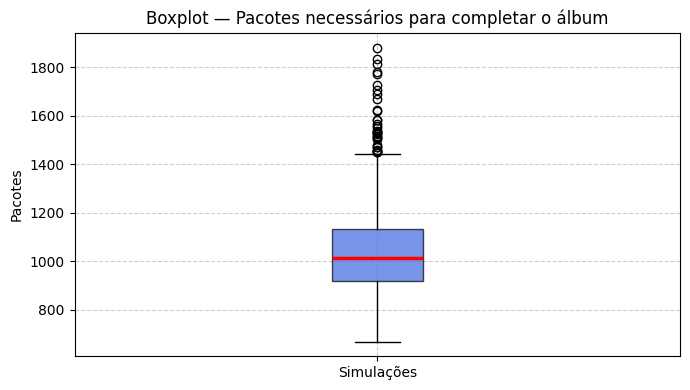

In [42]:
plt.figure(figsize=(7, 4))

plt.boxplot(df['pacotes_comprados'], patch_artist=True,
            boxprops=dict(facecolor='royalblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2.5))

plt.title('Boxplot — Pacotes necessários para completar o álbum')
plt.ylabel('Pacotes')
plt.xticks([1], ['Simulações'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusão**

O boxplot evidencia que a **maioria** das simulações ficou concentrada em uma faixa relativamente estreita, mas existem **vários** outliers na cauda superior, ou seja, simulações que precisaram de muito mais pacotes que o esperado.

Esse caso tem explicação, as últimas figurinhas são as mais difíceis de conseguir, e em alguns casos a aleatoriedade atrasa muito a conclusão do álbum.

---

# **6. 💰 Análise do Custo Total da Coleção**

Nesta seção é analisado o custo financeiro de completar o álbum. O custo total inclui:

- **Pacotes:** quantidade comprada × R$ 7,00

- **Álbum:** R$ 75,00 (capa dura, cobrado uma única vez)

#### **6.1 Média**

In [43]:
media_custo = df["custo_total"].mean()

print(f'Média de custo: R${media_custo:,.2f}')

Média de custo: R$7,393.92


**Conclusão**

O custo média para completar o álbum foi de aproximadamente **R$ 7.393,92**

Esse valor corresponde a comprar em torno de 1046 pacotes, mais o valor do álbum.

---

#### **6.2 Custo Mínimo e Máximo**

In [44]:
custo_minimo = df["custo_total"].min()
custo_maximo = df["custo_total"].max()

print(f'Menor valor encontrado: R${custo_minimo:,.2f}')
print(f'Maior valor encontrado: R${custo_maximo:,.2f}')
print(f'Diferença entre extremos: R${custo_maximo - custo_minimo:,.2f}')

Menor valor encontrado: R$4,758.00
Maior valor encontrado: R$13,242.00
Diferença entre extremos: R$8,484.00


**Conclusão**

O melhor cenário completou o álbum por **R\$ 4.758,00**, enquanto o pior cenário chegou a **R\$ 13.242,00**. Uma diferença de  **R$ 8.484,00** entre os extremos.

Isso reforça como a aleatoriedade pode impactar significativamente o bolso: dois colecionadores com o mesmo comportamento de compra podem ter gastos muito distintos.

---

#### **6.3 Mediana**

In [45]:
mediana_custo = df["custo_total"].median()

print(f'Mediana dos custos: R${mediana_custo}')

Mediana dos custos: R$7166.0


**Conclusão**

A mediana foi de **R\$ 7.166,00**, um pouco abaixo da média de **R$7.393,00**.

A diferença leve entre os dois indica que existem alguns casos de custo muito alto puxando a média para cima, mas para a maioria das pessoas, o valor esperado fica mais próximo da mediana.

---

#### **6.4 Quartis**

In [19]:
quartis_custo = df["custo_total"].quantile([0.25, 0.50, 0.75])

quartis_custo

,custo_total
0.25,6515.00
0.50,7166.00
0.75,7993.75


**Conclusão**

Os quartis mostram a faixa onde a maioria dos colecionadores vai se encaixar:

- **25% das simulações** custaram menos de **R\$ 6.515,00**
- **75% das simulações** custaram menos de **R\$ 7.993,7a5**
- Portanto, metade dos colecionadores podem esperar um gasto na faixa de **R\$ 6.529,00** e **R$ 7.982,00**

---

#### **6.5 Intervalo de Confiança (95%)**

O intervalo de confiança estima, com base nas 1.000 simulações, a faixa onde o **custo médio real** deve se encontrar.

Utiliza-se 95% de confiança.

In [48]:
ic_inferior = media_custo - 1.96 * (df['custo_total'].std() / np.sqrt(len(df)))
ic_superior = media_custo + 1.96 * (df['custo_total'].std() / np.sqrt(len(df)))

print(f'Com 95% de confiança, o custo médio fica entre:')
print(f'R${ic_inferior:,.2f}  →  R${ic_superior:,.2f}')

Com 95% de confiança, o custo médio fica entre:
R$7,314.64  →  R$7,473.20


**Conclusão**

Com 95% de confiança, o custo médio real de completar o álbum está entre **R\$ 7.314,64 e R$ 7.473,20**.

O intervalo estreito se deve ao alto número de simulações (1.000), o que torna a estimativa bastante precisa.

---

#### **6.6 Distribuição dos custos — Histograma**

O histograma abaixo mostra como os custos se distribuíram entre as 1.000 simulações.

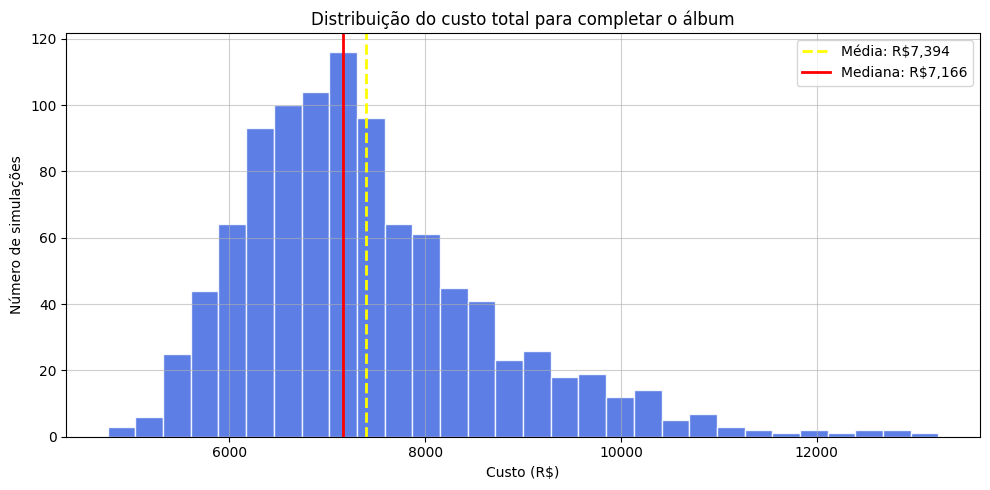

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(df['custo_total'], bins=30, color='royalblue', alpha=0.85, edgecolor='white')

plt.axvline(media_custo, linestyle='--', linewidth=2, color='yellow',
            label=f'Média: R${media_custo:,.0f}')
plt.axvline(mediana_custo, linestyle='-', linewidth=2, color='red',
            label=f'Mediana: R${mediana_custo:,.0f}')

plt.title('Distribuição do custo total para completar o álbum')
plt.xlabel('Custo (R$)')
plt.ylabel('Número de simulações')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusão**

A distribuição dos custos tem o mesmo comportamento da distribuição de pacotes. Concentração em torno da média com uma cauda longa à direita, gerada pelos casos de azar extremo.

A maior parte das simulações ficou entre **R\$ 6.000** e **R\$ 8.000**, enquanto casos acima de **R$ 10.000** existem mas são raros.

---

#### **6.7 Boxplot — Custo total**



---


####**6.6 Gráfico BloxPlot**

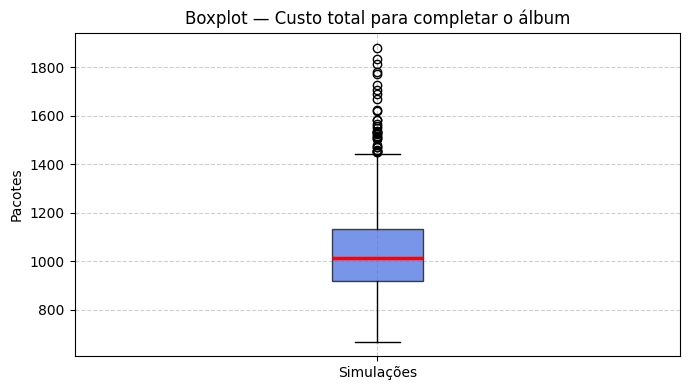

In [55]:
plt.figure(figsize=(7, 4))

plt.boxplot(df['pacotes_comprados'], patch_artist=True,
            boxprops=dict(facecolor='royalblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2.5))

plt.title('Boxplot — Custo total para completar o álbum')
plt.ylabel('Pacotes')
plt.xticks([1], ['Simulações'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusão**

O boxplot confirma o comportamento visto no histograma: a caixa central (onde estão 50% das simulações) é relativamente compacta, mas há outliers expressivos na parte superior representando os cenários de custo muito alto.

Esses casos extremos são raros, mas reais, e é exatamente por isso que trocas com outros colecionadores fazem diferença tão grande para reduzir o custo.

---

# **7. 🔁 Análise das Figurinhas Repetidas**

Nesta etapa é analisada a quantidade de figurinhas repetidas geradas nas simulações.

As repetidas representam cromos comprados que já estavam na coleção, elas são o principal fator que aumenta o custo total, já que o colecionador continua pagando por figurinhas que não precisam mais.

Serão analisados:
- Média e mediana de repetidas totais
- Comparação entre repetidas normais e brilhantes
- Impacto percentual das repetidas no total de figurinhas compradas

#### **7.1 Média e Mediana das Repetidas Totais**

In [56]:
media_repetidas = df['repetidas_total'].mean()
mediana_repetidas = df['repetidas_total'].median()

print(f'Média de figurinhas repetidas:  {media_repetidas:.0f}')
print(f'Mediana de figurinhas repetidas: {mediana_repetidas:.0f}')
print(f'Diferença média/mediana: {media_repetidas - mediana_repetidas:.0f} figurinhas')

Média de figurinhas repetidas:  6339
Mediana de figurinhas repetidas: 6111
Diferença média/mediana: 228 figurinhas


**Conclusão**

A média de repetidas foi de **6.339 figurinhas** e a mediana de **6.111**.

A diferença de 228 figurinhas entre os dois valores confirma que, assim como no custo, existem casos extremos puxando a média levemente para cima, mas o comportamento típico fica próximo da mediana.

Para contextualizar: o álbum tem **980 figurinhas** no total. Isso significa que, em média, cada figurinha do álbum é comprada mais de **7 vezes** ao longo do processo.

---

#### **7.2 Comparação entre Repetidas Normais e Brilhantes**

As figurinhas do álbum se dividem em dois grupos com características diferentes:
- **Normais (912):** jogadores das seleções
- **Brilhantes (68):** figurinha `00`, `FWC1-19` e escudos das 48 seleções

A seguir, é comparada a média de repetidas geradas por cada grupo.

In [57]:
media_normais = df["repetidas_normais"].mean()
media_brilhantes = df["repetidas_brilhantes"].mean()

print(f"Média repetidas normais: {media_normais:.0f}")
print(f"Média repetidas brilhantes: {media_brilhantes:.0f}")
print(f'Proporção normais/brilhantes: {media_normais/media_brilhantes:.1f}x')

Média repetidas normais: 5898
Média repetidas brilhantes: 441
Proporção normais/brilhantes: 13.4x


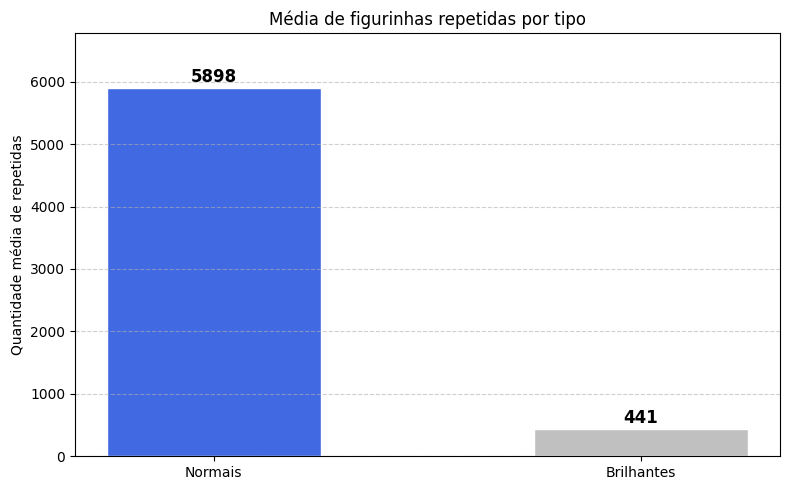

In [63]:
plt.figure(figsize=(8,5))

barras = plt.bar(
    ["Normais", "Brilhantes"],
    [media_normais, media_brilhantes],
    color =['royalblue', '#C0C0C0'],
    edgecolor='white', width=0.5
)

for bar, val in zip(barras, [media_normais, media_brilhantes]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Média de figurinhas repetidas por tipo')
plt.ylabel('Quantidade média de repetidas')
plt.ylim(0, max(media_normais, media_brilhantes) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusão**

As figurinhas normais geraram em média **5.898 repetidas**, contra **441 das brilhantes**, uma proporção de aproximadamente **13x** mais repetidas normais.

Esse resultado faz sentido: as figurinhas normais são 912 (93% do álbum) e têm muito mais chance de aparecer nos pacotes. Já as brilhantes são apenas 68, gerando bem menos repetidas,mas proporcionalmente, como são raras, cada repetida de uma brilhante é especialmente frustrante.

---

#### **7.3 Impacto das Repetidas na Coleção**

Aqui é calculado o percentual médio de figurinhas compradas que eram repetidas — ou seja, quanto do investimento total serviu apenas para gerar cromos duplicados.

In [64]:
media_repetidas = df["repetidas_total"].mean()
media_pacotes = df["pacotes_comprados"].mean()

figurinhas_compradas = media_pacotes * 7
percentual_repetidas = (media_repetidas / figurinhas_compradas) * 100

print(f'Média de figurinhas compradas no total: {figurinhas_compradas:.0f}')
print(f'Média de figurinhas repetidas:          {media_repetidas:.0f}')
print(f'Percentual médio de repetidas:          {percentual_repetidas:.1f}%')

Média de figurinhas compradas no total: 7319
Média de figurinhas repetidas:          6339
Percentual médio de repetidas:          86.6%


**Conclusão**

Aproximadamente **86,6%** de todas as figurinhas compradas eram repetidas.

Em outras palavras, a cada 7 figurinhas tiradas de um pacote, em média **6 delas** já estavam na coleção, especialmente nas fases finais do álbum, quando restam poucas figurinhas para completar e a chance de tirar algo novo despenca.

Esse fenômeno é conhecido como o *paradoxo do colecionador*: o custo marginal de cada figurinha nova aumenta exponencialmente à medida que o álbum se completa.

---

# **8. 🧾 Variação de Custos das Simulações**

Para analisar como os custos variaram entre as 1.000 simulações, o gráfico de linha abaixo exibe os valores da coluna `custo_total` **ordenados do menor para o maior**.

A linha horizontal indica a média, e as áreas coloridas destacam as simulações acima e abaixo dela.

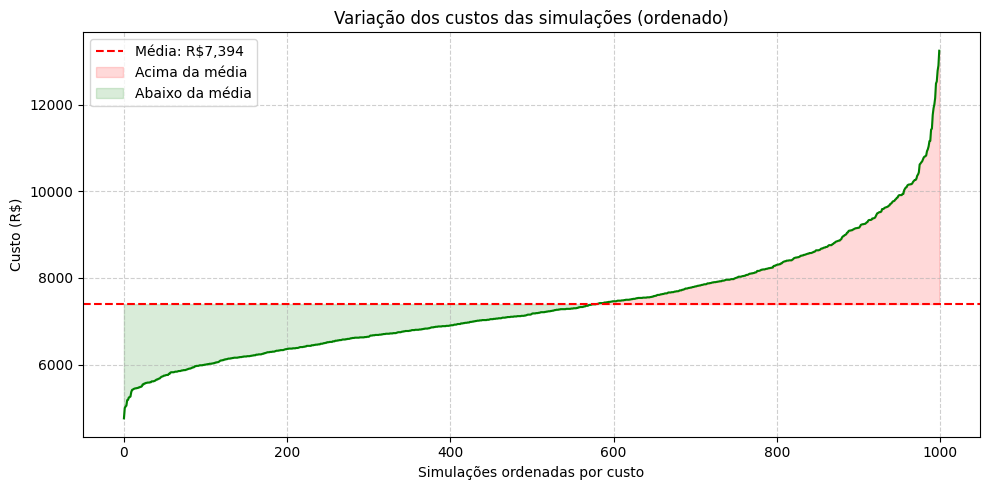

In [73]:
plt.figure(figsize=(10, 5))

custos_ordenados = df['custo_total'].sort_values().values

plt.plot(custos_ordenados, color='green', linewidth=1.5)

plt.axhline(media_custo, linestyle='--', color='red', linewidth=1.5,
            label=f'Média: R${media_custo:,.0f}')

plt.fill_between(range(len(custos_ordenados)), custos_ordenados, media_custo,
                 where=(custos_ordenados > media_custo), alpha=0.15, color='red',
                 label='Acima da média')
plt.fill_between(range(len(custos_ordenados)), custos_ordenados, media_custo,
                 where=(custos_ordenados <= media_custo), alpha=0.15, color='green',
                 label='Abaixo da média')

plt.title('Variação dos custos das simulações (ordenado)')
plt.xlabel('Simulações ordenadas por custo')
plt.ylabel('Custo (R$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusão**

O gráfico deixa evidente que a grande maioria das simulações ficou em uma faixa de custo relativamente estável, mas a curva sobe de forma acentuada nos últimos casos, os outliers de custo mais alto.

A área vermelha (acima da média) tem uma cauda bem mais longa e elevada do que a área verde (abaixo da média), confirmando a assimetria à direita da distribuição: é mais fácil gastar muito mais do que a média do que muito menos.

---

# **9. 🔗 Matriz de Correlação**

A matriz de correlação mede o grau de relacionamento entre as variáveis do dataset.

Os valores variam entre -1 e 1:
- **1:** correlação positiva perfeita → as duas variáveis crescem juntas
- **0:** sem correlação
- **-1:** correlação negativa perfeita → uma cresce quando a outra diminui

Os números são exibidos dentro de cada célula para facilitar a leitura direta dos valores.

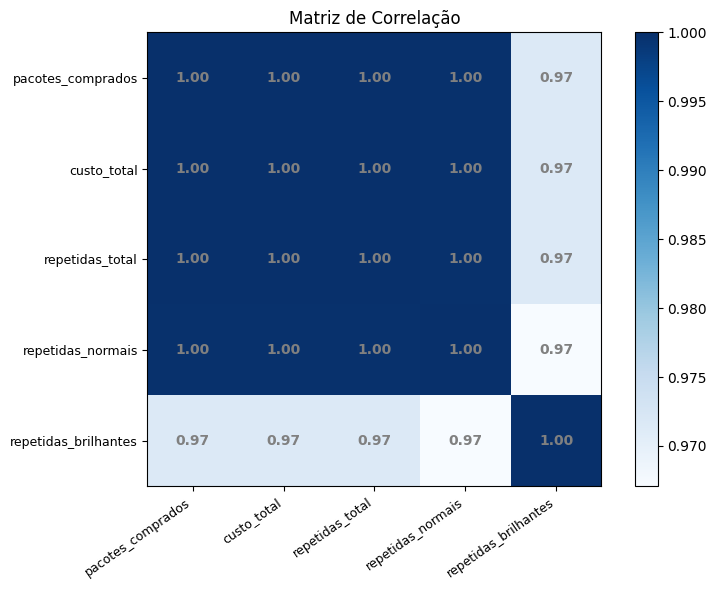

In [80]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr, cmap='Blues')
plt.colorbar(im, ax=ax)

cols = corr.columns.tolist()
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(cols, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        cor_txt = 'grey'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, color=cor_txt, fontweight='bold')

ax.set_title('Matriz de Correlação')
plt.tight_layout()
plt.show()

**Conclusão**

A matriz revela que todas as variáveis têm correlação positiva muito alta entre si (valores próximos de 1,0).

Isso era esperado e faz sentido estruturalmente:
- Mais pacotes comprados → mais figurinhas ao todo → mais repetidas
- Mais pacotes → custo mais alto
- Mais repetidas normais → mais repetidas totais

A única variável com correlação levemente menor com as demais é `repetidas_brilhantes`, o que faz sentido: as brilhantes são raras (apenas 68 no álbum), então o número de repetidas brilhantes cresce mais lentamente e com menos previsibilidade do que as normais.

---

# **10. 🏁 Conclusões Gerais**

Com base nas **1.000 simulações** realizadas, é possível traçar um panorama completo do custo e esforço necessários para completar o álbum da Copa do Mundo 2026, sem realizar trocas.

---

### 📦 Pacotes

| Métrica | Valor |
|---|---|
| Média | 1.046 pacotes |
| Mediana | 1.013 pacotes |
| Mínimo (melhor caso) | 669 pacotes |
| Máximo (pior caso) | 1.881 pacotes |
| 50% das simulações | entre 922 e 1.131 pacotes |

---

### 💰 Custo Total

| Métrica | Valor |
|---|---|
| Média | R\$ 7.393,92 |
| Mediana | R\$ 7.166,00 |
| Mínimo (melhor caso) | R\$ 4.758,00 |
| Máximo (pior caso) | R\$ 13.242,00 |
| 50% das simulações | entre R\$ 6.515 e R\$ 7.993,7a5 |
| Intervalo de confiança 95% | R\$ 7.314,64 a R\$ 7.473,20 |

---

### 🔁 Repetidas

| Métrica | Valor |
|---|---|
| Média de repetidas totais | 6.339 figurinhas |
| Repetidas normais (média) | 5.898 |
| Repetidas brilhantes (média) | 441 |
| % de figurinhas compradas que eram repetidas | 86,6% |

---

### 🔍 Principais Aprendizados

1. **O custo é alto e a variação é grande.** A diferença entre o melhor e o pior cenário chega a quase R$ 9.000. A aleatoriedade tem impacto real e significativo.

2. **Mais de 86% das figurinhas compradas são repetidas.** O colecionador passa a maior parte do tempo (e dinheiro) comprando cromos que já tem.

3. **As últimas figurinhas são as mais caras.** O custo marginal de cada figurinha nova cresce exponencialmente à medida que o álbum se completa.

4. **Trocas seriam transformadoras.** Com a taxa de repetidas em 86%, um sistema eficiente de trocas poderia reduzir drasticamente o custo, mas isso fica como análise futura.

5. **A distribuição tem cauda à direita.** É mais provável gastar muito mais do que a média do que muito menos, quem está com azar pode chegar facilmente ao dobro do custo típico.